In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/Cornell-University/arxiv/arxiv-metadata-oai-snapshot.json


**NOTEBOOK-1 Data Understanding & Preprocessing**

In [2]:
# =========================================================
# Task 1: Data Understanding & Preprocessing (Full Dataset)
# =========================================================
import json
import pandas as pd
import re
import spacy
import os
from tqdm import tqdm
import gc # Garbage Collector for explicit memory management

# Load spaCy model (Disable parser/ner for faster processing)
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

In [3]:
def clean_abstract(text):
    """
    Cleans research abstracts by removing LaTeX, URLs, punctuation, 
    and applying lemmatization and stop-word removal.
    """
    if not isinstance(text, str):
        return ""
        
    text = text.replace('\n', ' ')
    text = re.sub(r'\$.*?\$', '', text) # Remove LaTeX
    text = re.sub(r'http\S+|www\S+|@\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove non-alphabetic chars
    
    doc = nlp(text.lower())
    cleaned_tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop and len(token.lemma_) > 2
    ]
    
    return " ".join(cleaned_tokens)

In [4]:
dataset_path = '/kaggle/input/datasets/organizations/Cornell-University/arxiv/arxiv-metadata-oai-snapshot.json'
output_path = '/kaggle/working/cleaned_arxiv_full.csv'

# Define chunk size: 50,000 papers per batch is safe for Kaggle RAM
CHUNK_SIZE = 50000 

# 1. Initialize the CSV with headers first
pd.DataFrame(columns=['id', 'title', 'categories', 'clean_abstract']).to_csv(output_path, index=False)

records = []
chunk_counter = 1
total_processed = 0

print("Starting full dataset chunking process...")

# 2. Open the JSON and read line-by-line
with open(dataset_path, 'r') as f:
    for line in f:
        paper = json.loads(line)
        records.append({
            'id': paper.get('id', ''),
            'title': paper.get('title', ''),
            'categories': paper.get('categories', ''),
            'abstract': paper.get('abstract', '')
        })
        
        # 3. When the list hits 50,000, process the chunk
        if len(records) == CHUNK_SIZE:
            print(f"Processing Chunk {chunk_counter} (Papers {total_processed + 1} to {total_processed + CHUNK_SIZE})...")
            
            df_chunk = pd.DataFrame(records)
            
            # Apply cleaning (tqdm is removed here to prevent thousands of progress bars printing)
            df_chunk['clean_abstract'] = df_chunk['abstract'].apply(clean_abstract)
            
            # Append this cleaned chunk to the CSV file on disk
            df_chunk[['id', 'title', 'categories', 'clean_abstract']].to_csv(output_path, mode='a', header=False, index=False)
            
            # 4. Critical Step: Clear the RAM
            total_processed += len(records)
            records = [] # Empty the list
            del df_chunk # Delete the dataframe
            gc.collect() # Force Python to free up the memory
            
            chunk_counter += 1

# 5. Process any remaining papers that didn't fill the final chunk
if records:
    print(f"Processing Final Chunk {chunk_counter}...")
    df_chunk = pd.DataFrame(records)
    df_chunk['clean_abstract'] = df_chunk['abstract'].apply(clean_abstract)
    df_chunk[['id', 'title', 'categories', 'clean_abstract']].to_csv(output_path, mode='a', header=False, index=False)
    total_processed += len(records)
    del df_chunk
    gc.collect()

print(f"\nSuccess! Completely processed {total_processed} papers. Saved to {output_path}")

Starting full dataset chunking process...
Processing Chunk 1 (Papers 1 to 50000)...
Processing Chunk 2 (Papers 50001 to 100000)...
Processing Chunk 3 (Papers 100001 to 150000)...
Processing Chunk 4 (Papers 150001 to 200000)...
Processing Chunk 5 (Papers 200001 to 250000)...
Processing Chunk 6 (Papers 250001 to 300000)...
Processing Chunk 7 (Papers 300001 to 350000)...
Processing Chunk 8 (Papers 350001 to 400000)...
Processing Chunk 9 (Papers 400001 to 450000)...
Processing Chunk 10 (Papers 450001 to 500000)...
Processing Chunk 11 (Papers 500001 to 550000)...
Processing Chunk 12 (Papers 550001 to 600000)...
Processing Chunk 13 (Papers 600001 to 650000)...
Processing Chunk 14 (Papers 650001 to 700000)...
Processing Chunk 15 (Papers 700001 to 750000)...
Processing Chunk 16 (Papers 750001 to 800000)...
Processing Chunk 17 (Papers 800001 to 850000)...
Processing Chunk 18 (Papers 850001 to 900000)...
Processing Chunk 19 (Papers 900001 to 950000)...
Processing Chunk 20 (Papers 950001 to 10000

In [5]:
# To prove it worked, we read back just a random sample from our new giant CSV
print("Loading a sample of the final dataset for verification...")

# Read a random 10,000 rows to get dataset statistics without blowing up RAM
df_sample = pd.read_csv(output_path).sample(n=10000, random_state=42)

print("\n--- SAMPLE ROWS ---")
display(df_sample.head())

print("\n--- SAMPLE STATISTICS ---")
display(df_sample.describe(include='all'))

Loading a sample of the final dataset for verification...


/tmp/ipykernel_17/2921488041.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sample = pd.read_csv(output_path).sample(n=10000, random_state=42)



--- SAMPLE ROWS ---


,id,title,categories,clean_abstract
2967469,quant-ph/9908078,"Identity, Geometry, Permutation And The Spin-S...",quant-ph hep-th physics.ed-ph,examine historic formulation spin statistic th...
338921,1204.6659,Luminous Infrared Galaxies With the Submillime...,astro-ph.GA astro-ph.CO,high resolution observation local ...
1063232,1812.05658,"Comment on ""Distinct Thresholds for the Initia...",physics.ao-ph physics.geo-ph,martin kok measure distinct aeolian salt...
2844247,hep-th/9708118,New Curves from Branes,hep-th,consider configuration neveu schwarz fivebrane...
1733545,2210.1219,The Bergman number of a plane domain,math.CV,let domain complex plane hardy number introduc...



--- SAMPLE STATISTICS ---


,id,title,categories,clean_abstract
count,10000.00000,10000,10000,10000
unique,10000.00000,10000,2357,10000
top,2506.02917,Text-guided Generation of Efficient Personaliz...,cs.CV,propose training free vision language model vl...
freq,1.00000,1,304,1


Generating Abstract Length Distribution...


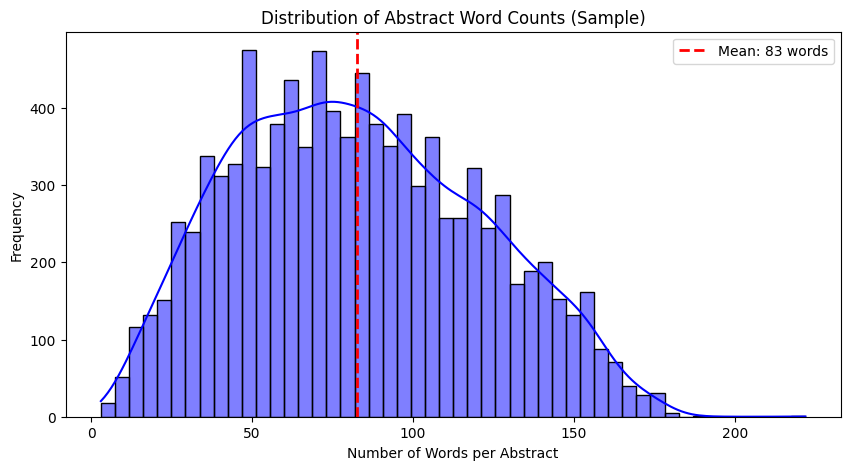

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Abstract Length Distribution...")

# Calculate the number of words in each cleaned abstract
df_sample['word_count'] = df_sample['clean_abstract'].dropna().apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_sample['word_count'], bins=50, kde=True, color='blue')
plt.title('Distribution of Abstract Word Counts (Sample)')
plt.xlabel('Number of Words per Abstract')
plt.ylabel('Frequency')
plt.axvline(df_sample['word_count'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df_sample['word_count'].mean():.0f} words")
plt.legend()
plt.show()

Analyzing Top Research Categories...


/tmp/ipykernel_17/1416270012.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[cat[1] for cat in top_10_categories], y=[cat[0] for cat in top_10_categories], palette='magma')


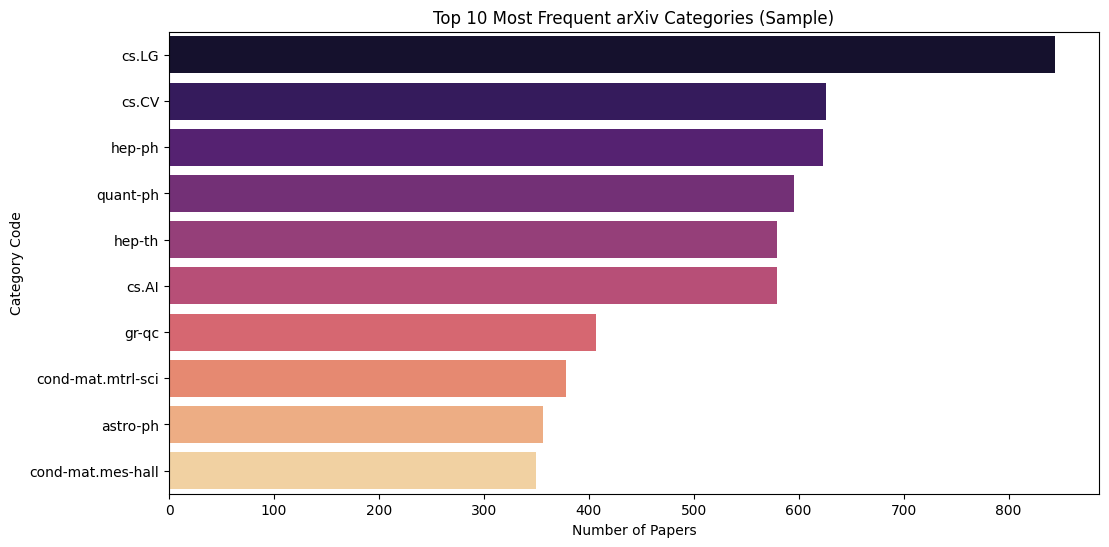

In [7]:
from collections import Counter

print("Analyzing Top Research Categories...")

# Categories are space-separated (e.g., "cs.AI stat.ML"). We need to split and count them.
all_categories = ' '.join(df_sample['categories'].dropna()).split()
category_counts = Counter(all_categories)
top_10_categories = category_counts.most_common(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=[cat[1] for cat in top_10_categories], y=[cat[0] for cat in top_10_categories], palette='magma')
plt.title('Top 10 Most Frequent arXiv Categories (Sample)')
plt.xlabel('Number of Papers')
plt.ylabel('Category Code')
plt.show()

Extracting Most Common Words...


/tmp/ipykernel_17/1296100160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[word[1] for word in common_words], y=[word[0] for word in common_words], palette='viridis')


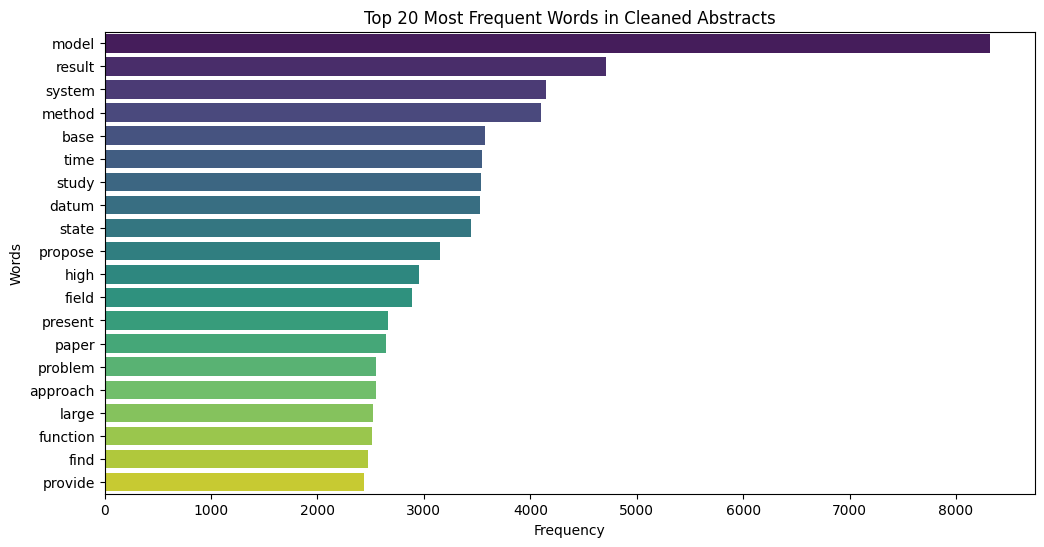

In [8]:
print("Extracting Most Common Words...")

# Extract all words to find the most common ones
all_words = ' '.join(df_sample['clean_abstract'].dropna()).split()
word_counts = Counter(all_words)
common_words = word_counts.most_common(20)

# Plotting the top 20 words
plt.figure(figsize=(12, 6))
sns.barplot(x=[word[1] for word in common_words], y=[word[0] for word in common_words], palette='viridis')
plt.title('Top 20 Most Frequent Words in Cleaned Abstracts')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()